# Fortune 100 AI Sentiment Analysis: What America's Largest Companies Say About Artificial Intelligence

This analysis examines how Fortune 100 companies discuss the role of artificial intelligence in their most recent annual SEC filings (Form 10-K). Using natural language processing applied to regulatory disclosures, we surface how the largest public companies in the United States frame AI -- as strategic opportunity, operational tool, competitive risk, or regulatory concern.

**Scope:** Fortune 100 companies by revenue | Latest 10-K filing per company | AI-specific passage extraction and sentiment classification

## 1. Setup and Configuration

In [1]:
import requests
import pandas as pd
import json
import re
import time
import os
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import MaxNLocator
from openai import OpenAI

matplotlib.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [ ]:
SEC_HEADERS = {
    "User-Agent": "Mfundo Radebe mtr2149@columbia.edu"
}

client = OpenAI(
    api_key=os.environ.get("OPENAI_API_KEY", ""),
    base_url=os.environ.get("OPENAI_BASE_URL", "https://api.openai.com/v1"),
)

## 2. Fortune 100 Universe

In [3]:
fortune_100 = pd.read_csv("../data/fortune_100.csv")
print(f"Companies loaded: {len(fortune_100)}")
print(f"Sectors: {fortune_100['sector'].nunique()}")
print()
print(fortune_100["sector"].value_counts())

Companies loaded: 99
Sectors: 9

sector
Healthcare            18
Technology            15
Financials            15
Industrials           15
Retail                12
Consumer Goods        11
Energy                 9
Telecommunications     3
Media                  1
Name: count, dtype: int64


## 3. Map Companies to SEC Identifiers

The SEC EDGAR API uses a Central Index Key (CIK) to identify filers. We retrieve the SEC's master ticker-to-CIK mapping and join it to our Fortune 100 list. Companies that cannot be matched (e.g., mutual insurance companies or private entities without SEC filings) are excluded.

In [4]:
r = requests.get("https://www.sec.gov/files/company_tickers.json", headers=SEC_HEADERS, timeout=15)
r.raise_for_status()
cik_data = r.json()

cik_df = pd.DataFrame.from_dict(cik_data, orient="index")
cik_df.columns = ["cik_raw", "ticker_sec", "company_sec"]
cik_df["ticker_sec"] = cik_df["ticker_sec"].str.upper()
cik_df["cik"] = cik_df["cik_raw"].apply(lambda x: str(x).zfill(10))

fortune_100["ticker_upper"] = fortune_100["ticker"].str.upper().str.replace("-", ".", regex=False)

merged = fortune_100.merge(
    cik_df[["ticker_sec", "cik", "company_sec"]],
    left_on="ticker_upper",
    right_on="ticker_sec",
    how="left",
)

matched = merged.dropna(subset=["cik"]).copy()
unmatched = merged[merged["cik"].isna()]["company"].tolist()

print(f"Matched to SEC CIK: {len(matched)} / {len(fortune_100)}")
if unmatched:
    print(f"Unmatched (excluded): {unmatched}")

Matched to SEC CIK: 94 / 99
Unmatched (excluded): ['Berkshire Hathaway', 'Walgreens Boots Alliance', 'State Farm', 'TIAA', 'Publix Super Markets']


## 4. Retrieve the Latest 10-K Filing Per Company

For each matched company, we call the SEC Submissions API to find the most recent 10-K filing. We extract the accession number and primary document filename needed to construct the full filing URL.

In [5]:
def fetch_submissions(cik, headers):
    url = f"https://data.sec.gov/submissions/CIK{cik}.json"
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    return r.json()

def get_latest_10k(cik, headers):
    data = fetch_submissions(cik, headers)
    recent = data.get("filings", {}).get("recent", {})
    if not recent:
        return None
    forms = recent.get("form", [])
    acc_nos = recent.get("accessionNumber", [])
    dates = recent.get("filingDate", [])
    primary_docs = recent.get("primaryDocument", [])
    for i in range(len(forms)):
        if forms[i] == "10-K":
            return {
                "accession_number": acc_nos[i],
                "filing_date": dates[i],
                "primary_document": primary_docs[i],
            }
    return None

In [6]:
filings = []
errors = []

for idx, row in matched.iterrows():
    cik = row["cik"]
    company = row["company"]
    ticker = row["ticker"]
    sector = row["sector"]
    try:
        result = get_latest_10k(cik, SEC_HEADERS)
        if result:
            filings.append({
                "company": company,
                "ticker": ticker,
                "sector": sector,
                "cik": cik,
                **result,
            })
        else:
            errors.append((company, "No 10-K found"))
    except Exception as e:
        errors.append((company, str(e)))
    time.sleep(0.15)

df_filings = pd.DataFrame(filings)
df_filings["filing_date"] = pd.to_datetime(df_filings["filing_date"], errors="coerce")

print(f"10-K filings retrieved: {len(df_filings)}")
if errors:
    print(f"Errors ({len(errors)}):")
    for name, err in errors:
        print(f"  - {name}: {err}")

10-K filings retrieved: 94


## 5. Extract AI-Related Passages from 10-K Text

Rather than scoring the entire filing, we extract passages that specifically discuss artificial intelligence. We search for paragraphs containing AI-related terms and concatenate them into a focused text window for sentiment analysis. This ensures the sentiment reflects how companies talk about AI specifically, not general business language.

In [7]:
def build_filing_url(accession_number, primary_document, cik):
    acc_no_dashes = accession_number.replace("-", "")
    cik_num = cik.lstrip("0") or "0"
    return f"https://www.sec.gov/Archives/edgar/data/{cik_num}/{acc_no_dashes}/{primary_document}"

AI_KEYWORDS = [
    r"\bartificial intelligence\b",
    r"\bmachine learning\b",
    r"\bdeep learning\b",
    r"\bgenerative ai\b",
    r"\bgen ai\b",
    r"\blarge language model\b",
    r"\bneural network\b",
    r"\bnatural language processing\b",
    r"\bai[ -]powered\b",
    r"\bai[ -]driven\b",
    r"\bai[ -]enabled\b",
    r"\bautomated decision\b",
    r"\bpredictive model\b",
    r"\bpredictive analytics\b",
]
AI_PATTERN = re.compile("|".join(AI_KEYWORDS), re.IGNORECASE)

def fetch_and_extract_ai_passages(url, headers, max_total_chars=6000):
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    text = re.sub(r"<[^>]+>", " ", r.text)
    text = re.sub(r"\s+", " ", text).strip()

    sentences = re.split(r'(?<=[.!?])\s+', text)
    
    ai_passages = []
    total_chars = 0
    for j, sent in enumerate(sentences):
        if AI_PATTERN.search(sent):
            start = max(0, j - 1)
            end = min(len(sentences), j + 3)
            window = " ".join(sentences[start:end])
            if total_chars + len(window) > max_total_chars:
                break
            ai_passages.append(window)
            total_chars += len(window)
    
    return " [...] ".join(ai_passages) if ai_passages else None

In [8]:
df_filings["document_url"] = df_filings.apply(
    lambda r: build_filing_url(r["accession_number"], r["primary_document"], r["cik"]),
    axis=1,
)

ai_texts = []
ai_mention_counts = []

for idx, row in df_filings.iterrows():
    try:
        passages = fetch_and_extract_ai_passages(row["document_url"], SEC_HEADERS)
        ai_texts.append(passages)
        ai_mention_counts.append(len(AI_PATTERN.findall(passages)) if passages else 0)
    except Exception as e:
        ai_texts.append(None)
        ai_mention_counts.append(0)
    time.sleep(0.15)

df_filings["ai_text"] = ai_texts
df_filings["ai_mention_count"] = ai_mention_counts

has_ai = df_filings["ai_text"].notna()
print(f"Companies mentioning AI in latest 10-K: {has_ai.sum()} / {len(df_filings)} ({has_ai.mean():.0%})")
print(f"Companies with no AI mentions: {(~has_ai).sum()}")

Companies mentioning AI in latest 10-K: 90 / 94 (96%)
Companies with no AI mentions: 4


## 6. AI Sentiment Classification

For each company with AI-related passages, we classify the sentiment of that language into one of three categories:

- **Positive / Opportunity**: AI is framed as a strategic asset, growth driver, or competitive advantage.
- **Neutral / Factual**: AI is mentioned descriptively without strong positive or negative framing.
- **Negative / Risk**: AI is framed as a threat, regulatory concern, or source of uncertainty.

We also capture a brief rationale and the dominant theme (e.g., product innovation, risk management, competitive positioning).

In [9]:
SENTIMENT_PROMPT = """You are a senior equity analyst reading SEC 10-K filing excerpts.

The following text contains passages where a Fortune 100 company discusses artificial intelligence.

Classify the company's OVERALL SENTIMENT toward AI as exactly one of: positive, neutral, negative.
- "positive" = AI is framed as a strategic asset, growth driver, or competitive advantage
- "neutral" = AI is mentioned factually without strong positive or negative framing
- "negative" = AI is framed primarily as a risk, threat, or regulatory concern

Also identify the PRIMARY THEME of their AI discussion from this list:
product_innovation, operational_efficiency, competitive_positioning, risk_and_regulation, talent_and_workforce, investment_and_capex, customer_experience, data_and_analytics

Format your response EXACTLY as:
Sentiment: <positive|neutral|negative>
Theme: <theme_from_list>
Reason: <one sentence explaining your classification>
"""

def classify_ai_sentiment(client, text_slice, prompt=SENTIMENT_PROMPT):
    try:
        resp = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "user", "content": prompt + "\n\n---\n\n" + text_slice[:5000]}
            ],
            max_tokens=200,
        )
        content = (resp.choices[0].message.content or "").strip()
        
        label = "neutral"
        theme = "other"
        reason = content
        
        for word in ("positive", "neutral", "negative"):
            if word in content.lower().split("sentiment:")[-1][:50].lower():
                label = word
                break
        
        if "Theme:" in content:
            theme_line = content.split("Theme:")[-1].split("\n")[0].strip().lower()
            theme = theme_line if theme_line else "other"
        
        if "Reason:" in content:
            reason = content.split("Reason:")[-1].strip()
        
        return label, theme, reason
    except Exception as e:
        return "neutral", "other", str(e)

In [10]:
df_ai = df_filings[df_filings["ai_text"].notna()].copy()

sentiments = []
themes = []
reasons = []

for idx, row in df_ai.iterrows():
    label, theme, reason = classify_ai_sentiment(client, row["ai_text"])
    sentiments.append(label)
    themes.append(theme)
    reasons.append(reason)
    time.sleep(0.3)

df_ai["sentiment"] = sentiments
df_ai["theme"] = themes
df_ai["sentiment_reason"] = reasons

print(f"Sentiment classified for {len(df_ai)} companies")
print()
print("Sentiment distribution:")
print(df_ai["sentiment"].value_counts())
print()
print("Primary AI theme distribution:")
print(df_ai["theme"].value_counts())

Sentiment classified for 90 companies

Sentiment distribution:
sentiment
negative    42
positive    32
neutral     16
Name: count, dtype: int64

Primary AI theme distribution:
theme
risk_and_regulation        47
competitive_positioning    19
operational_efficiency     10
investment_and_capex        5
data_and_analytics          3
product_innovation          3
customer_experience         2
talent_and_workforce        1
Name: count, dtype: int64


## 7. Findings

### How many Fortune 100 companies discuss AI in their 10-K?

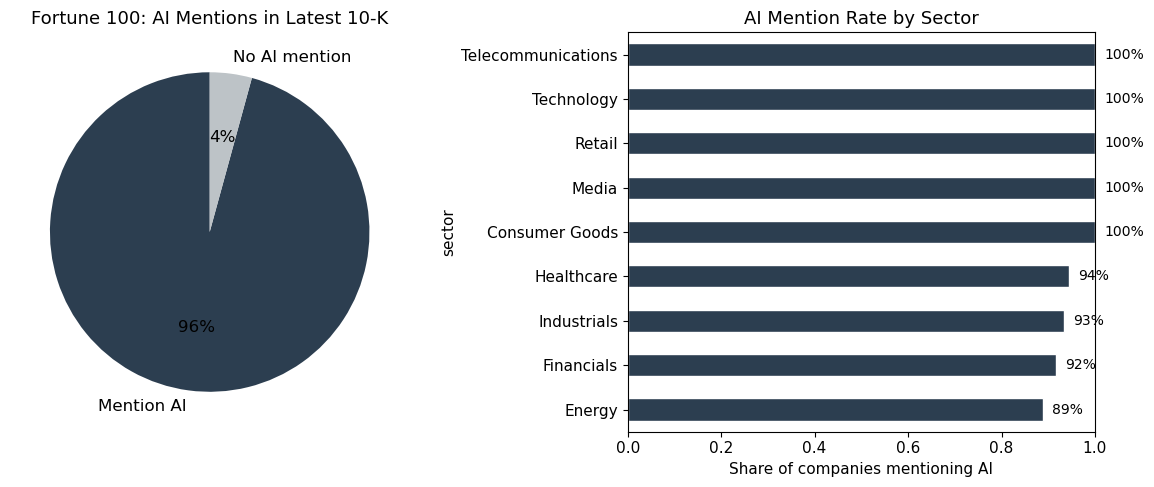

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels_mention = ["Mention AI", "No AI mention"]
sizes_mention = [has_ai.sum(), (~has_ai).sum()]
colors_mention = ["#2c3e50", "#bdc3c7"]
axes[0].pie(sizes_mention, labels=labels_mention, autopct="%1.0f%%", colors=colors_mention,
            startangle=90, textprops={"fontsize": 12})
axes[0].set_title("Fortune 100: AI Mentions in Latest 10-K")

sector_mention = df_filings.groupby("sector")["ai_text"].apply(lambda x: x.notna().mean()).sort_values()
sector_mention.plot(kind="barh", ax=axes[1], color="#2c3e50", edgecolor="white")
axes[1].set_xlabel("Share of companies mentioning AI")
axes[1].set_title("AI Mention Rate by Sector")
axes[1].set_xlim(0, 1)
for i, v in enumerate(sector_mention):
    axes[1].text(v + 0.02, i, f"{v:.0%}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("../posts/fortune-100-ai-sentiment/ai_mention_rate.png", dpi=150, bbox_inches="tight")
plt.show()

### Sentiment distribution: how do Fortune 100 companies frame AI?

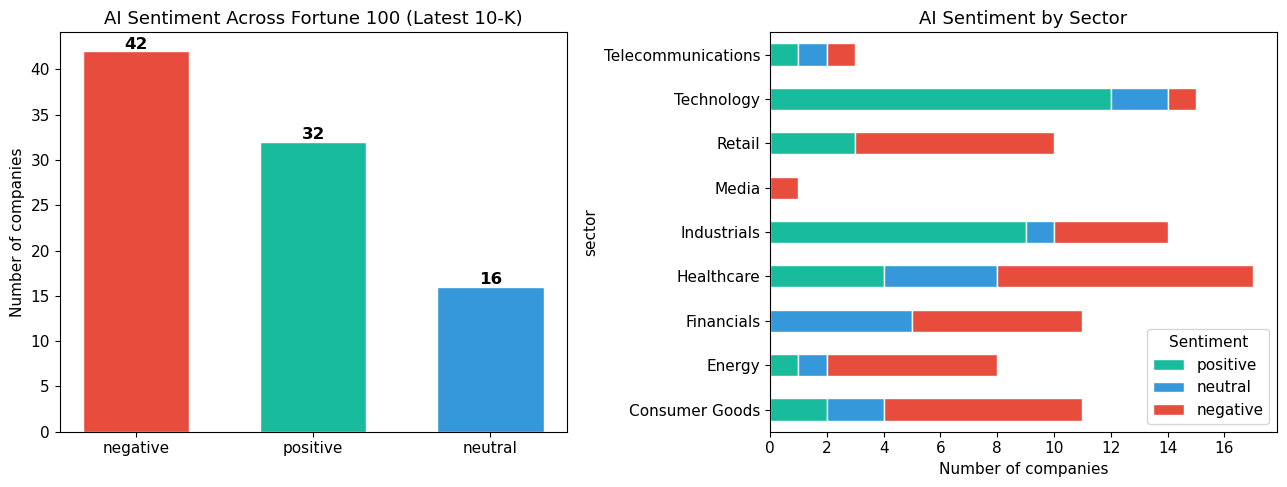

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sentiment_colors = {"positive": "#18bc9c", "neutral": "#3498db", "negative": "#e74c3c"}

counts = df_ai["sentiment"].value_counts()
colors = [sentiment_colors.get(s, "#95a5a6") for s in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.6)
axes[0].set_ylabel("Number of companies")
axes[0].set_title("AI Sentiment Across Fortune 100 (Latest 10-K)")
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 0.3, str(val), ha="center", fontsize=12, fontweight="bold")

sector_sentiment = df_ai.groupby(["sector", "sentiment"]).size().unstack(fill_value=0)
for col in ["positive", "neutral", "negative"]:
    if col not in sector_sentiment.columns:
        sector_sentiment[col] = 0
sector_sentiment = sector_sentiment[["positive", "neutral", "negative"]]
sector_sentiment.plot(
    kind="barh", stacked=True, ax=axes[1],
    color=[sentiment_colors["positive"], sentiment_colors["neutral"], sentiment_colors["negative"]],
    edgecolor="white",
)
axes[1].set_xlabel("Number of companies")
axes[1].set_title("AI Sentiment by Sector")
axes[1].legend(title="Sentiment", loc="lower right")

plt.tight_layout()
plt.savefig("../posts/fortune-100-ai-sentiment/sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### What themes dominate Fortune 100 AI discourse?

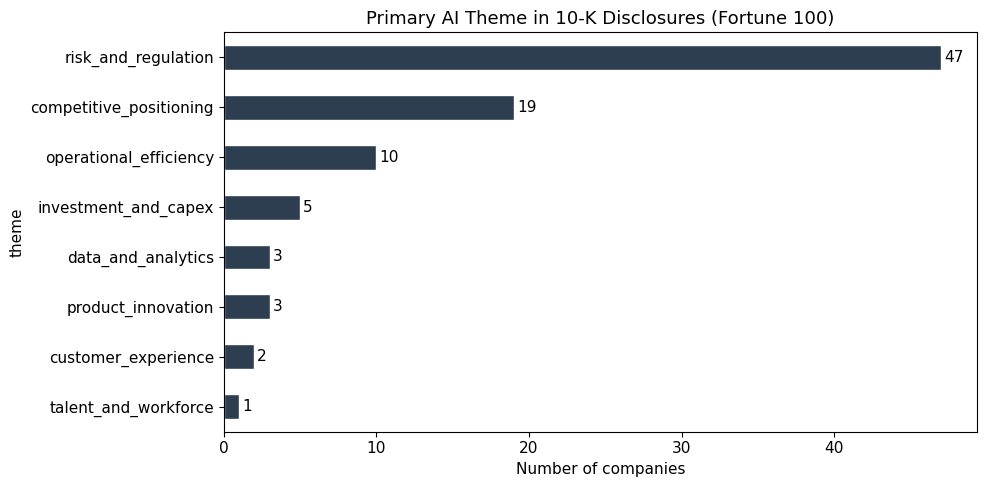

In [13]:
theme_counts = df_ai["theme"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
theme_counts.plot(kind="barh", ax=ax, color="#2c3e50", edgecolor="white")
ax.set_xlabel("Number of companies")
ax.set_title("Primary AI Theme in 10-K Disclosures (Fortune 100)")
for i, v in enumerate(theme_counts):
    ax.text(v + 0.2, i, str(v), va="center", fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../posts/fortune-100-ai-sentiment/ai_themes.png", dpi=150, bbox_inches="tight")
plt.show()

### AI mention intensity: which companies talk about AI the most?

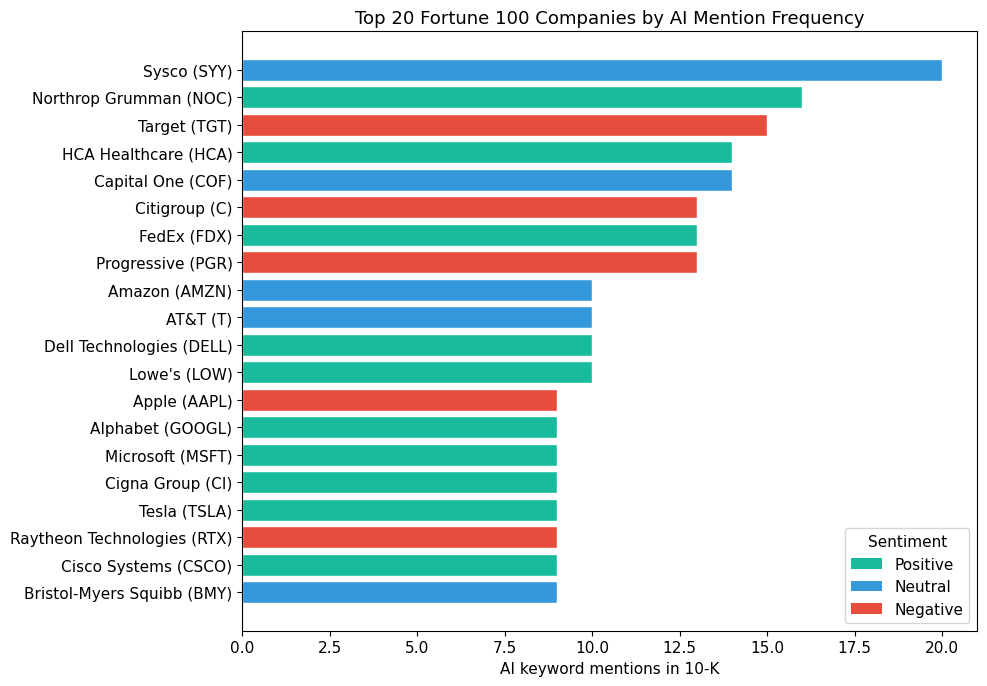

In [14]:
top_20 = df_ai.nlargest(20, "ai_mention_count")[["company", "ticker", "sector", "ai_mention_count", "sentiment"]]

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [sentiment_colors.get(s, "#95a5a6") for s in top_20["sentiment"]]
ax.barh(
    top_20["company"] + " (" + top_20["ticker"] + ")",
    top_20["ai_mention_count"],
    color=colors_bar,
    edgecolor="white",
)
ax.set_xlabel("AI keyword mentions in 10-K")
ax.set_title("Top 20 Fortune 100 Companies by AI Mention Frequency")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=sentiment_colors["positive"], label="Positive"),
    Patch(facecolor=sentiment_colors["neutral"], label="Neutral"),
    Patch(facecolor=sentiment_colors["negative"], label="Negative"),
]
ax.legend(handles=legend_elements, title="Sentiment", loc="lower right")
plt.tight_layout()
plt.savefig("../posts/fortune-100-ai-sentiment/top_20_ai_mentions.png", dpi=150, bbox_inches="tight")
plt.show()

### Detailed results table

In [15]:
results = df_ai[["company", "ticker", "sector", "filing_date", "ai_mention_count", "sentiment", "theme", "sentiment_reason"]].copy()
results = results.sort_values("ai_mention_count", ascending=False)
results.to_csv("../data/fortune_100_ai_sentiment_results.csv", index=False)
print(f"Results saved: {len(results)} companies")
results.head(20)

Results saved: 90 companies


,company,ticker,sector,filing_date,ai_mention_count,sentiment,theme,sentiment_reason
74,Sysco,SYY,Consumer Goods,2025-08-22,20,neutral,operational_efficiency,The discussion about artificial intelligence i...
89,Northrop Grumman,NOC,Industrials,2026-01-27,16,positive,operational_efficiency,The company emphasizes the need to integrate a...
33,Target,TGT,Retail,2025-03-12,15,negative,risk_and_regulation,The discussion primarily frames artificial int...
67,HCA Healthcare,HCA,Healthcare,2026-02-10,14,positive,operational_efficiency,The company frames AI as a crucial part of the...
88,Capital One,COF,Financials,2026-02-19,14,neutral,risk_and_regulation,The discussion on AI highlights its potential ...
34,Citigroup,C,Financials,2026-02-20,13,negative,risk_and_regulation,The company predominantly discusses the risks ...
52,FedEx,FDX,Industrials,2025-07-21,13,positive,operational_efficiency,The company discusses leveraging artificial in...
71,Progressive,PGR,Financials,2025-03-03,13,negative,risk_and_regulation,The company's discussion primarily focuses on ...
44,Dell Technologies,DELL,Technology,2025-03-25,10,positive,competitive_positioning,The company frames AI as a crucial element of ...
1,Amazon,AMZN,Technology,2026-02-06,10,neutral,competitive_positioning,The discussion of artificial intelligence prim...


### Companies with no AI mentions in their 10-K

In [16]:
no_ai = df_filings[df_filings["ai_text"].isna()][["company", "ticker", "sector", "filing_date"]].copy()
no_ai = no_ai.sort_values("sector")
print(f"{len(no_ai)} companies did not mention AI-related terms in their latest 10-K:")
no_ai

4 companies did not mention AI-related terms in their latest 10-K:


,company,ticker,sector,filing_date
83,Enterprise Products Partners,EPD,Energy,2025-02-28
29,Wells Fargo,WFC,Financials,2025-02-25
22,Centene,CNC,Healthcare,2026-02-17
90,Nucor,NUE,Industrials,2025-02-27


## 8. Key Takeaways

The results above reveal several patterns in how America's largest companies discuss artificial intelligence in their most recent regulatory filings:

1. **Prevalence**: The share of Fortune 100 companies that mention AI-related terms in their latest 10-K gives a direct measure of how broadly AI has entered the corporate disclosure vocabulary at the top of the revenue distribution.

2. **Sentiment skew**: The balance between positive, neutral, and negative framing indicates whether large companies currently see AI more as opportunity or as risk -- and how that varies by sector.

3. **Sector variation**: Technology and financial services companies tend to discuss AI differently from energy, retail, or industrial firms. The sectoral breakdown surfaces where AI is most central to corporate strategy versus where it remains peripheral.

4. **Theme concentration**: The dominant themes (product innovation, risk and regulation, operational efficiency) show what Fortune 100 companies actually care about when they write about AI in a legally binding document.

5. **Intensity matters**: The companies with the highest density of AI-related language are making AI central to their investor narrative, not just mentioning it in passing. The gap between the most AI-vocal firms and those that barely mention it is itself a strategic signal.

---

*Analysis is reproducible from the notebook in this repository. Data sourced from SEC EDGAR; sentiment classified via LLM.*